# SARIMA Prediction Test

This notebook loads a saved SARIMA model from SARIMA/models and evaluates the last 6 months (180 days) for a selected category and region.

In [80]:
from __future__ import annotations

import ast
import json
import re
import unicodedata
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "data").exists():
    ROOT_DIR = ROOT_DIR.parent

DATA_PATH = ROOT_DIR / "data" / "ecommerce_algerie_2024_2025_version10mai.csv"
REGIONS_PATH = ROOT_DIR / "wilayas_regions.txt"
MODELS_DIR = ROOT_DIR / "SARIMA" / "models"

DATE_COL = "date"
CATEGORY_COL = "category"
REGION_COL = "region"
DEMAND_COL = "demand"

FORECAST_STEPS = 180
MIN_LENGTH = 24

In [81]:
def _normalize_text(value: str) -> str:
    text = str(value).strip().lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def _slugify(value: str) -> str:
    text = str(value).strip().lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^a-z0-9]+", "-", text)
    return text.strip("-") or "unknown"


def _find_column(columns: list[str], target_normalized: str) -> str:
    for column in columns:
        if _normalize_text(column) == target_normalized:
            return column
    raise KeyError(f"Missing required column: {target_normalized}")


def _load_regions_map() -> dict[str, str]:
    raw_text = REGIONS_PATH.read_text(encoding="utf-8")
    cleaned_text = re.sub(r",\s*([}\]])", r"\1", raw_text)
    region_data = json.loads(cleaned_text)

    region_map: dict[str, str] = {}
    for region, wilayas in region_data.items():
        for wilaya in wilayas:
            region_map[_normalize_text(wilaya)] = region
    return region_map


def _prepare_aggregated(df: pd.DataFrame) -> pd.DataFrame:
    columns = df.columns.tolist()
    date_col = _find_column(columns, "date")
    category_col = _find_column(columns, "category")
    region_col = _find_column(columns, "region")
    demand_col = _find_column(columns, "demand")

    df = df.rename(
        columns={
            date_col: DATE_COL,
            category_col: CATEGORY_COL,
            region_col: REGION_COL,
            demand_col: DEMAND_COL,
        }
    )
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    df[DEMAND_COL] = pd.to_numeric(df[DEMAND_COL], errors="coerce")
    df = df.dropna(subset=[DATE_COL, CATEGORY_COL, REGION_COL, DEMAND_COL]).copy()
    return df.sort_values(DATE_COL)


def _prepare_raw(df: pd.DataFrame) -> pd.DataFrame:
    columns = df.columns.tolist()
    category_col = _find_column(columns, "categorie")
    date_col = _find_column(columns, "date expedition")
    wilaya_col = _find_column(columns, "destination wilaya")

    region_map = _load_regions_map()

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col, category_col, wilaya_col]).copy()

    df[REGION_COL] = (
        df[wilaya_col]
        .map(_normalize_text)
        .map(region_map)
        .fillna("unknown")
    )
    df[CATEGORY_COL] = df[category_col]
    df[DATE_COL] = df[date_col].dt.normalize()

    daily = (
        df.groupby([DATE_COL, CATEGORY_COL, REGION_COL], dropna=False)
        .size()
        .reset_index(name=DEMAND_COL)
        .sort_values([DATE_COL, CATEGORY_COL, REGION_COL])
    )
    return daily


def _load_data() -> pd.DataFrame:
    df = pd.read_csv(DATA_PATH)
    normalized_cols = {_normalize_text(col) for col in df.columns}
    has_aggregated = {"date", "category", "region", "demand"}.issubset(normalized_cols)

    if has_aggregated:
        return _prepare_aggregated(df)
    return _prepare_raw(df)


def _series_for(df: pd.DataFrame, category: str, region: str) -> pd.Series:
    ts = (
        df[(df[CATEGORY_COL] == category) & (df[REGION_COL] == region)]
        .groupby(DATE_COL, as_index=True)[DEMAND_COL]
        .sum()
        .sort_index()
    )
    return ts


def _model_path_for(category: str, region: str) -> Path:
    file_key = f"{_slugify(category)}_{_slugify(region)}"
    return MODELS_DIR / f"sarima_{file_key}.pkl"


def _load_saved_model(category: str, region: str):
    path = _model_path_for(category, region)
    if not path.exists():
        raise FileNotFoundError(
            f"Model not found at {path}. Run sarima_by_category_region.py first."
        )
    return joblib.load(path)

In [82]:
df = _load_data()
categories = sorted(df[CATEGORY_COL].unique())
regions = sorted(df[REGION_COL].unique())

print(f"{len(categories)} categories, {len(regions)} regions, {len(df)} rows")
categories[:10], regions[:10]

22 categories, 4 regions, 50902 rows


(['Animaux et articles pour animaux de compagnie',
  "Appareils photo, caméras et instruments d'optique",
  'Appareils électroniques',
  'Arts et loisirs',
  'Bagages et maroquinerie',
  'Bébés et tout-petits',
  'Entreprise et industrie',
  'Fournitures de bureau',
  'Jeux et jouets',
  'Logiciels'],
 ['centre', 'est', 'ouest', 'sud'])

In [83]:
# Update these to test another combination.
category = categories[0]
region = regions[0]

category, region

('Animaux et articles pour animaux de compagnie', 'centre')

In [84]:
ts = _series_for(df, category, region)
ts = ts.sort_index()

cutoff = ts.index.max() - pd.Timedelta(days=FORECAST_STEPS - 1)
test = ts[ts.index >= cutoff]
train = ts[ts.index < cutoff]

if len(train) < MIN_LENGTH:
    raise ValueError(f"Need at least {MIN_LENGTH} training points, got {len(train)}")
if test.empty:
    raise ValueError("Test window is empty. Check the forecast horizon or data range.")

len(train), len(test)

(538, 176)

In [85]:
fit = _load_saved_model(category, region)

prediction = fit.get_prediction(start=test.index[0], end=test.index[-1])
forecast = prediction.predicted_mean

fit.model.order

(1, 0, 1)

In [86]:
def _mae(y_true, y_pred) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def _rmse(y_true, y_pred) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def _mape(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if not mask.any():
        return float("nan")
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)

metrics = {
    "mae": _mae(test, forecast),
    "rmse": _rmse(test, forecast),
    "mape_percent": _mape(test, forecast),
}

metrics

{'mae': 1.8467263726047214,
 'rmse': 2.294522310404242,
 'mape_percent': 58.968797259681104}

## MSE testing

Mean squared error for the selected category and region.

In [87]:
mse = float(np.mean((test - forecast) ** 2))
mse

5.264832632942821

In [88]:
comparison = pd.DataFrame({"actual": test, "forecast": forecast})
comparison

,actual,forecast
date,,
2025-07-05,5,4.378426
2025-07-06,11,4.498607
2025-07-07,6,6.013429
2025-07-08,5,5.972706
2025-07-09,3,5.704583
...,...,...
2025-12-27,2,4.353927
2025-12-28,4,3.768119
2025-12-29,3,3.799628


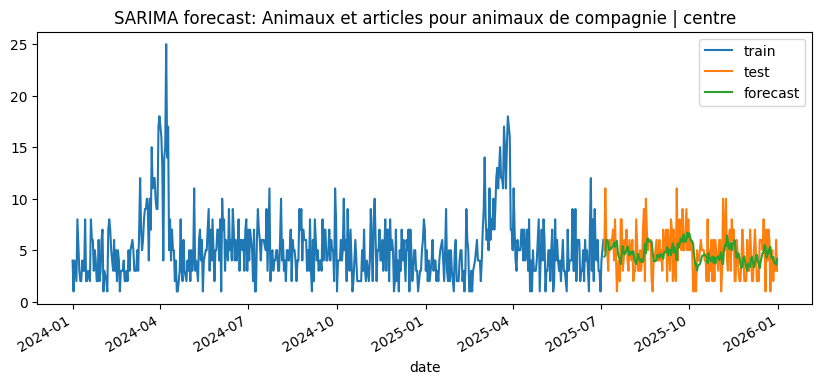

In [89]:
ax = train.plot(label="train", figsize=(10, 4))
test.plot(ax=ax, label="test")
forecast.plot(ax=ax, label="forecast")
ax.set_title(f"SARIMA forecast: {category} | {region}")
ax.legend()
plt.show()